<a href="https://colab.research.google.com/github/Aryasunil56/Heart_disease_assessment/blob/main/Arya_Assessment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Step 1:Load and explore data

In [ ]:
df=pd.read_csv("/content/heart_disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.shape

(1025, 14)

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
#checking missing values
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
#checking data types
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
numerical_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print("Column:", col)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print()

Column: age
Lower Bound: 28.5
Upper Bound: 80.5
Number of Outliers: 0

Column: trestbps
Lower Bound: 90.0
Upper Bound: 170.0
Number of Outliers: 30

Column: chol
Lower Bound: 115.0
Upper Bound: 371.0
Number of Outliers: 16

Column: thalach
Lower Bound: 81.0
Upper Bound: 217.0
Number of Outliers: 4

Column: oldpeak
Lower Bound: -2.7
Upper Bound: 4.5
Number of Outliers: 7



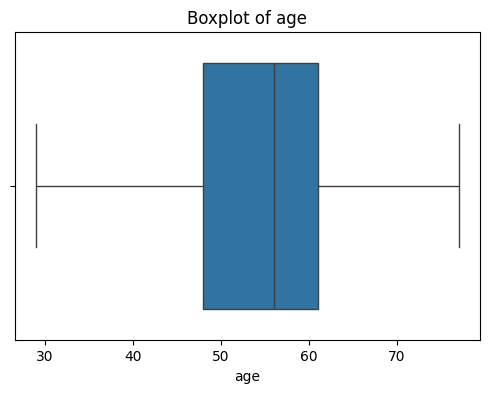

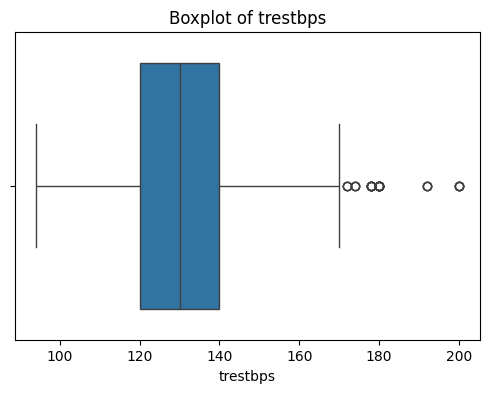

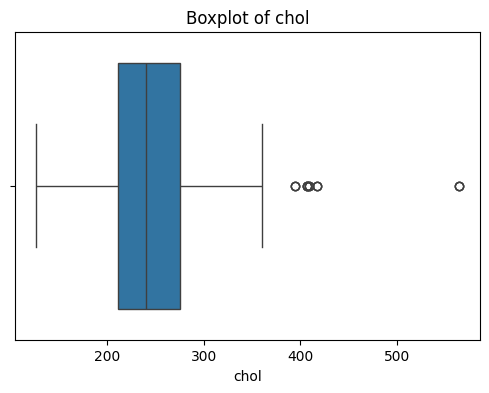

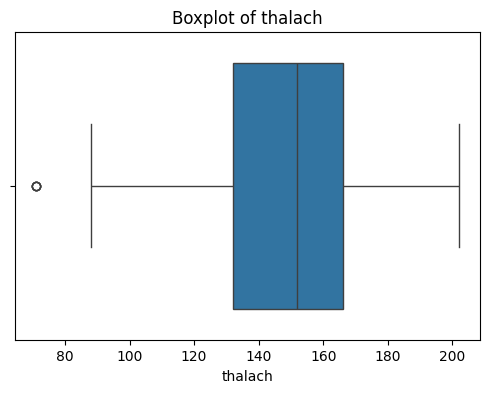

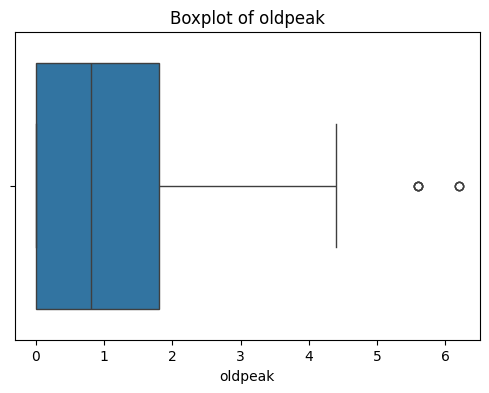

In [ ]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
categorical_columns = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'ca',
    'thal',
    'target'
]

In [ ]:
for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 sex
sex
1    713
0    312
Name: count, dtype: int64

 cp
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64

 fbs
fbs
0    872
1    153
Name: count, dtype: int64

 restecg
restecg
1    513
0    497
2     15
Name: count, dtype: int64

 exang
exang
0    680
1    345
Name: count, dtype: int64

 slope
slope
1    482
2    469
0     74
Name: count, dtype: int64

 ca
ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64

 thal
thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64

 target
target
1    526
0    499
Name: count, dtype: int64


#Step 2: Data Cleaning and Preprocessing

##1. Handle Missing Values

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
#there is no missing values in the dataset given

##2.Handle outliers

In [ ]:
outlier_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [ ]:
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

##3.Encode Categorical Variables



In [ ]:
df = pd.get_dummies(
    df,
    columns=['cp', 'restecg', 'thal'],
    dtype=int
)

In [ ]:
print(df['sex'].unique())
print(df['fbs'].unique())

[1 0]
[0 1]


##4.Scale Numerical Features:





In [ ]:
from sklearn.preprocessing import StandardScaler

scale_columns = ['trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()

X = df.drop(columns=['target'])
y = df['target']

X[scale_columns] = scaler.fit_transform(X[scale_columns])

In [ ]:
X[scale_columns].head()

,trestbps,chol,thalach,oldpeak
0,-0.378869,-0.691104,0.824084,-0.054537
1,0.528894,-0.879693,0.255654,1.785457
2,0.831481,-1.487368,-1.056105,1.347363
3,1.013034,-0.879693,0.518006,-0.930725
4,0.407859,1.027150,-1.886886,0.734031


#Step 3: Train-Test split

In [ ]:
#for regression
X_reg = df.drop(columns=['chol', 'target'])
y_reg = df['chol']

In [ ]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_reg_train:", X_reg_train.shape)
print("X_reg_test:", X_reg_test.shape)
print("y_reg_train:", y_reg_train.shape)
print("y_reg_test:", y_reg_test.shape)

X_reg_train: (820, 20)
X_reg_test: (205, 20)
y_reg_train: (820,)
y_reg_test: (205,)


In [ ]:
#classification
X_clf = df.drop(columns=['target'])
y_clf = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_clf_train:", X_clf_train.shape)
print("X_clf_test:", X_clf_test.shape)
print("y_clf_train:", y_clf_train.shape)
print("y_clf_test:", y_clf_test.shape)

X_clf_train: (820, 21)
X_clf_test: (205, 21)
y_clf_train: (820,)
y_clf_test: (205,)


#Step 4: Build Machine Learning Models


In [ ]:
#linear regression

In [ ]:
lr_model = LinearRegression()

In [ ]:
lr_model.fit(X_reg_train, y_reg_train)

LinearRegression()

In [ ]:
y_pred_lr = lr_model.predict(X_reg_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_reg_test, y_pred_lr))
print("MSE:", mean_squared_error(y_reg_test, y_pred_lr))
print("R²:", r2_score(y_reg_test, y_pred_lr))

MAE: 37.444200832676096
MSE: 2247.750518271938
R²: 0.07099901678372955


In [ ]:
#SVM
svm_model = SVR()

svm_model.fit(X_reg_train, y_reg_train)

y_pred_svm = svm_model.predict(X_reg_test)

In [ ]:
print("MAE:", mean_absolute_error(y_reg_test, y_pred_svm))
print("MSE:", mean_squared_error(y_reg_test, y_pred_svm))
print("R²:", r2_score(y_reg_test, y_pred_svm))

MAE: 39.47335291063378
MSE: 2465.9892256433027
R²: -0.01919959381639802


In [ ]:
#random forest
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_reg_train, y_reg_train)

y_pred_rf = rf_model.predict(X_reg_test)

In [ ]:
print("MAE:", mean_absolute_error(y_reg_test, y_pred_rf))
print("MSE:", mean_squared_error(y_reg_test, y_pred_rf))
print("R²:", r2_score(y_reg_test, y_pred_rf))

MAE: 8.272146341463413
MSE: 162.93893024390238
R²: 0.9326569273723644


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_clf_train, y_clf_train)

y_pred_log = log_model.predict(X_clf_test)

In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_clf_train, y_clf_train)

y_pred_knn = knn_model.predict(X_clf_test)

In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf_clf_model = RandomForestClassifier(random_state=42)

rf_clf_model.fit(X_clf_train, y_clf_train)

y_pred_rf_clf = rf_clf_model.predict(X_clf_test)

#Step 5: Evaluate Models on Test Data


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression")

print("MAE:", mean_absolute_error(y_reg_test, y_pred_lr))

print("MSE:", mean_squared_error(y_reg_test, y_pred_lr))

print("R²:", r2_score(y_reg_test, y_pred_lr))

Linear Regression
MAE: 37.444200832676096
MSE: 2247.750518271938
R²: 0.07099901678372955


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_clf_test, y_pred_log))
print("Precision:", precision_score(y_clf_test, y_pred_log))
print("Recall:", recall_score(y_clf_test, y_pred_log))
print("F1 Score:", f1_score(y_clf_test, y_pred_log))


# KNN
print("\nKNN")
print("Accuracy:", accuracy_score(y_clf_test, y_pred_knn))
print("Precision:", precision_score(y_clf_test, y_pred_knn))
print("Recall:", recall_score(y_clf_test, y_pred_knn))
print("F1 Score:", f1_score(y_clf_test, y_pred_knn))


# Random Forest
print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_clf_test, y_pred_rf_clf))
print("Precision:", precision_score(y_clf_test, y_pred_rf_clf))
print("Recall:", recall_score(y_clf_test, y_pred_rf_clf))
print("F1 Score:", f1_score(y_clf_test, y_pred_rf_clf))

Logistic Regression
Accuracy: 0.8097560975609757
Precision: 0.7622950819672131
Recall: 0.9029126213592233
F1 Score: 0.8266666666666667

KNN
Accuracy: 0.7365853658536585
Precision: 0.7333333333333333
Recall: 0.7475728155339806
F1 Score: 0.7403846153846154

Random Forest
Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1 Score: 0.9852216748768473


#Step 6: Summary

In [ ]:
###Regression summary
regression_results = pd.DataFrame({
    'Model': ['Linear Regression', 'SVM', 'Random Forest'],
    'MAE': [37.4442, 39.4734, 8.2721],
    'MSE': [2247.7505, 2465.9892, 162.9389],
    'R2': [0.0710, -0.0192, 0.9327]
})

regression_results

,Model,MAE,MSE,R2
0,Linear Regression,37.4442,2247.7505,0.0710
1,SVM,39.4734,2465.9892,-0.0192
2,Random Forest,8.2721,162.9389,0.9327


Best performing regression model: Random Forest, based on the highest R² score of 0.9327.

In [ ]:
###Classification summary
classification_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [0.8098, 0.7366, 0.9854],
    'Precision': [0.7623, 0.7333, 1.0000],
    'Recall': [0.9029, 0.7476, 0.9709],
    'F1 Score': [0.8267, 0.7404, 0.9852]
})

classification_results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8098,0.7623,0.9029,0.8267
1,KNN,0.7366,0.7333,0.7476,0.7404
2,Random Forest,0.9854,1.0000,0.9709,0.9852


Best performing classification model: Random Forest, based on the highest Recall score of 0.9709.

#Conclusion
The heart disease dataset was successfully preprocessed and used to build both regression and classification models. Among the evaluated models, Random Forest performed best in both categories, based on the selected performance metrics. Overall, the models provided useful results for predicting serum cholesterol and heart disease.